In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import CIFAR10

In [2]:
# Datasets & Dataloaders
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = CIFAR10(root="./data", train=True, download=True, transform=train_transform)
testset = CIFAR10(root="./data", train=False, download=True, transform=test_transform)

In [3]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64)

## Build the CNN

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # kernel size = 2, stride = 2

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # kernel size = 2, stride = 2

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # kernel size = 2, stride = 2
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # flattening
        x = self.fc_layers(x)

        return x

In [5]:
model = CNN()

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

## Training the CNN

In [7]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()

        output = model(images) # FP
        loss = criterion(output, labels) # loss fnx
        loss.backward() # BP
        optimizer.step() # update params

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(trainloader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
      for images, labels in testloader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_val_loss += loss.item()

      epoch_val_loss = running_val_loss / len(testloader)
      val_losses.append(epoch_val_loss)

    print(f"epoch={epoch+1}/{epochs} ==> train loss={epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
      best_val_loss = epoch_val_loss
      torch.save(model.state_dict(), "best_model.pt")

epoch=1/10 ==> train loss=1.559680829420114 & val loss = 1.2288370815811642
epoch=2/10 ==> train loss=1.2021445178467294 & val loss = 0.9908397569777859
epoch=3/10 ==> train loss=1.0056343952865552 & val loss = 0.8558185457423994
epoch=4/10 ==> train loss=0.8935028125562936 & val loss = 0.8155248588437487
epoch=5/10 ==> train loss=0.8250263531113524 & val loss = 0.7660651522077573
epoch=6/10 ==> train loss=0.7636993192041012 & val loss = 0.7460594845425551
epoch=7/10 ==> train loss=0.7228312688639097 & val loss = 0.674240447153711
epoch=8/10 ==> train loss=0.6873517727379299 & val loss = 0.685551804721735
epoch=9/10 ==> train loss=0.6567371263909523 & val loss = 0.6465043480608873
epoch=10/10 ==> train loss=0.6364330929106153 & val loss = 0.6351985367620068


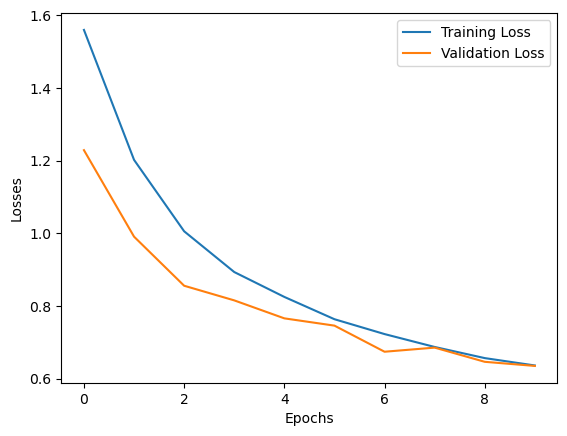

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [9]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [11]:
# Evaluate our CNN

correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images,labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy = {correct_labels / total_labels * 100}")

accuracy = 77.83
